In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import torch
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from transformers import AutoModel, AutoTokenizer
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import plotly as px
from plotly import graph_objects as go
from sklearn.preprocessing import StandardScaler

In [63]:
pd.options.display.max_columns = None
sample_dataset = pd.read_csv("./chexpert_sample_dataset.csv", index_col=0)
sample_dataset

,path_to_image,deid_patient_id,report,sub_report,target,report_length,sub_report_length
0,train/patient18877/study1/view1_frontal.jpg,patient18877,NARRATIVE:\nCHEST: Two views.\nCOMPARISON: 12-...,\nThere is plate-like atelectasis seen at the ...,0,110,76
1,train/patient28169/study1/view1_frontal.jpg,patient28169,IMPRESSION:\n \nCARDIAC SILHOUETTE IS AT THE U...,\n \nCARDIAC SILHOUETTE IS AT THE UPPER LIMITS...,1,95,74
2,train/patient58769/study1/view1_frontal.jpg,patient58769,NARRATIVE:\nChest 1 View: 1-11-2020\n \nHISTOR...,\n \nUnchanged right internal jugular venous ...,1,86,48
3,train/patient54916/study1/view1_frontal.jpg,patient54916,NARRATIVE:\nChest 1 View: 6/6/2008\n \nHISTORY...,\n \n1. PORTABLE UPRIGHT FRONTAL CHEST RADIO...,1,100,68
4,train/patient01990/study1/view1_frontal.jpg,patient01990,NARRATIVE:\nCHEST:\nCLINICAL HISTORY: Check li...,\nThere is an endotracheal tube with its tip a...,1,152,118
...,...,...,...,...,...,...,...
21995,train/patient08833/study1/view1_frontal.jpg,patient08833,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nRedemonstration of right IJ central venou...,0,109,57
21996,train/patient63772/study1/view1_frontal.jpg,patient63772,"NARRATIVE:\nChest 1 View Portable, 09-01-14\n ...",\n \n1.STABLE POSITIONING OF THE LEFT CHEST ...,0,121,75
21997,train/patient46004/study1/view1_frontal.jpg,patient46004,"NARRATIVE:\nEXAM: Chest Post Needle Biopsy, 20...",\n \n1. SEMI-UPRIGHT FRONTAL VIEW OF THE CHEST...,1,101,59
21998,train/patient07484/study1/view1_frontal.jpg,patient07484,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 9-28-20...,\n \n UPRIGHT PORTABLE CHEST WITHOUT COMPARIS...,1,64,35


In [64]:
X = sample_dataset.drop(columns=["target"])
y = sample_dataset["target"]

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# BiomedCLIP

In [66]:
# Load the BiomedCLIP model and processor
model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

def check_biomed_clip_match(image_path, report_text):
    # Prepare inputs
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = tokenizer([report_text]).to(device)
    
    with torch.no_grad():
        # Get features
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)
        
        # Normalize features
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Calculate similarity score (ranges roughly from -1 to 1, usually >0)
        similarity = (image_features @ text_features.T).item()
        
    return similarity

## Test on full raw reports --> report column

Here, we try on report columns that contain the full report of the doctor.

In [67]:
X_train["similarity_score"] = 0.0
for i in X_train.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_train.loc[i, "path_to_image"]
    report_text = X_train.loc[i, "report"]
    X_train.loc[i, "similarity_score"] = check_biomed_clip_match(image_path, report_text)

Test ROC-AUC Score: 0.7102
Optimal Similarity Threshold: 0.4010
Maximized True Positive Rate (Sensitivity): 0.6289
Minimized False Positive Rate (1 - Specificity): 0.3105


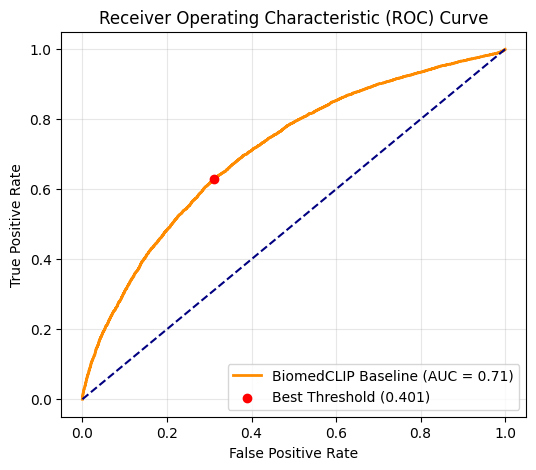

In [68]:
targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()

def evaluate(targets, similarities):
    # Compute ROC-AUC Score
    auc = roc_auc_score(targets, similarities)
    print(f"Test ROC-AUC Score: {auc:.4f}")
    
    # Calculate ROC Curve metrics
    fpr, tpr, thresholds = roc_curve(targets, similarities)
    
    # Find optimal threshold using Youden's J statistic: J = TPR - FPR
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    
    print(f"Optimal Similarity Threshold: {best_threshold:.4f}")
    print(f"Maximized True Positive Rate (Sensitivity): {tpr[best_idx]:.4f}")
    print(f"Minimized False Positive Rate (1 - Specificity): {fpr[best_idx]:.4f}")
    
    # Optional: Plot the ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'BiomedCLIP Baseline (AUC = {auc:.2f})', color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold ({best_threshold:.3f})', zorder=5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_threshold

opt_threshold = evaluate(targets, similarities)

In [69]:
def bin_classif_metrics(similarities, targets, opt_threshold, type='Train'):
    # Convert continuous similarity scores into binary predictions (0 or 1)
    predictions = (similarities >= opt_threshold).astype(int)

    # Calculate operational metrics
    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions)  # Out of all predicted matches, how many are real?
    recall = recall_score(targets, predictions)        # Same as Sensitivity / True Positive Rate
    f1 = f1_score(targets, predictions)                # Harmonic mean of Precision and Recall

    # Extract Specificity (True Negative Rate) via Confusion Matrix
    # Matrix format: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(targets, predictions).ravel()
    specificity = tn / (tn + fp)

    # Print the evaluation dashboard
    print(f"--- Operational Metrics at Threshold {opt_threshold} ---")
    print(f"{type} ROC-AUC Score: {roc_auc_score(targets, similarities):.4f}")
    print(f"{type} Accuracy:    {accuracy:.4f}")
    print(f"{type} Precision:   {precision:.4f}")
    print(f"{type} Recall:      {recall:.4f}")
    print(f"{type} F1-Score:    {f1:.4f}")
    print(f"{type} Specificity: {specificity:.4f} (FPR is {1-specificity:.4f})")

In [70]:
print("----------Train metrics-------------")
targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Train')

print("----------Test metrics-------------")
X_test["similarity_score"] = 0.0
for i in X_test.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_test.loc[i, "path_to_image"]
    report_text = X_test.loc[i, "report"]
    X_test.loc[i, "similarity_score"] = check_biomed_clip_match(image_path, report_text)
targets = y_test.to_numpy()
similarities = X_test["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Test')

----------Train metrics-------------
--- Operational Metrics at Threshold 0.40102702379226685 ---
Train ROC-AUC Score: 0.7102
Train Accuracy:    0.6592
Train Precision:   0.6695
Train Recall:      0.6289
Train F1-Score:    0.6485
Train Specificity: 0.6895 (FPR is 0.3105)
----------Test metrics-------------
--- Operational Metrics at Threshold 0.40102702379226685 ---
Test ROC-AUC Score: 0.7245
Test Accuracy:    0.6677
Test Precision:   0.6818
Test Recall:      0.6291
Test F1-Score:    0.6544
Test Specificity: 0.7064 (FPR is 0.2936)


## Test on finding+impression+summary section --> sub_report column

Here, we try on some subsections(findings,impression and summary) of the doctor's report that focus on the medical description of the radio.

In [71]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [72]:
X_train["sub_similarity_score"] = 0.0
for i in X_train.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_train.loc[i, "path_to_image"]
    report_text = X_train.loc[i, "sub_report"]
    X_train.loc[i, "sub_similarity_score"] = check_biomed_clip_match(image_path, report_text)

Test ROC-AUC Score: 0.7062
Optimal Similarity Threshold: 0.3810
Maximized True Positive Rate (Sensitivity): 0.6931
Minimized False Positive Rate (1 - Specificity): 0.3784


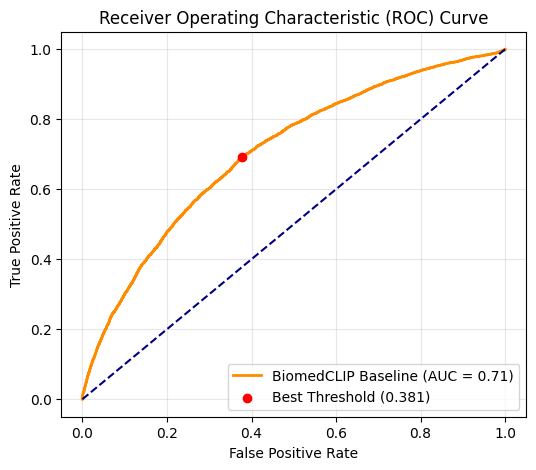

In [73]:
targets = y_train.to_numpy()
similarities = X_train["sub_similarity_score"].to_numpy()
opt_threshold = evaluate(targets, similarities)

In [75]:
print("----------Train metrics-------------")
targets = y_train.to_numpy()
similarities = X_train["sub_similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Train')

print("----------Test metrics-------------")
X_test["sub_similarity_score"] = 0.0
for i in X_test.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_test.loc[i, "path_to_image"]
    report_text = X_test.loc[i, "sub_report"]
    X_test.loc[i, "sub_similarity_score"] = check_biomed_clip_match(image_path, report_text)
targets = y_test.to_numpy()
similarities = X_test["sub_similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Test')

----------Train metrics-------------
--- Operational Metrics at Threshold 0.38104182481765747 ---
Train ROC-AUC Score: 0.7062
Train Accuracy:    0.6573
Train Precision:   0.6468
Train Recall:      0.6931
Train F1-Score:    0.6692
Train Specificity: 0.6216 (FPR is 0.3784)
----------Test metrics-------------
--- Operational Metrics at Threshold 0.38104182481765747 ---
Test ROC-AUC Score: 0.7223
Test Accuracy:    0.6648
Test Precision:   0.6533
Test Recall:      0.7023
Test F1-Score:    0.6769
Test Specificity: 0.6273 (FPR is 0.3727)


Results are not good (random). It seems that BiomedCLIP model was trained on raw full reports

## Use a simple logistic regression on encoded vectors

Instead of computing a similarity score between image and text vectors, we'll use the encoded vectors directly in a logistic regression model.
We use the full doctors reports.

In [343]:
# model, preprocess, tokenizer, and device are already set up from BiomedCLIP
def extract_multimodal_features(image_path, report_text):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = tokenizer([report_text]).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)
        
        # Normalize the vectors
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Move to CPU and convert to numpy for scikit-learn
        img_emb = image_features.cpu().numpy().flatten()
        txt_emb = text_features.cpu().numpy().flatten()
        
    # Combine features: Absolute difference and Element-wise product --> similarities and differences
    abs_diff = np.abs(img_emb - txt_emb)
    product = img_emb * txt_emb
    
    # Concatenate them to create a single robust feature vector for this pair
    combined_feature = np.concatenate([img_emb, txt_emb, abs_diff, product])
    return combined_feature


In [344]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [345]:
# Extract multimodal features for train and test sets:
reg_X_train = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_train["path_to_image"]).tolist(), X_train["report"].tolist())])
reg_y_train = y_train.to_numpy()

reg_X_test = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_test["path_to_image"]).tolist(), X_test["report"].tolist())])
reg_y_test = y_test.to_numpy()

In [347]:
scaler = StandardScaler()
reg_X_train_std = scaler.fit_transform(reg_X_train)
reg_X_test_std = scaler.transform(reg_X_test)

In [161]:
# Train Logistic Regression
""" log_reg = LogisticRegression(max_iter=10000, random_state=42) 
log_reg.fit(reg_X_train_std[:, :], reg_y_train) """

log_reg = LogisticRegression(max_iter=10000, random_state=42) 
log_reg.fit(reg_X_train, reg_y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [162]:
# Predict probabilities on the tain and test sets
# predict_proba returns [prob_of_0, prob_of_1]. We want prob_of_1.
""" y_probs_train = log_reg.predict_proba(reg_X_train_std[:, :])[:, 1]
y_preds_train = log_reg.predict(reg_X_train_std[:, :])
y_probs_test = log_reg.predict_proba(reg_X_test_std[:, :])[:, 1]
y_preds_test = log_reg.predict(reg_X_test_std[:, :])

# Evaluate
print("----------Train metrics-------------")
print(f"Train ROC-AUC Score: {roc_auc_score(reg_y_train, y_probs_train):.4f}")
print("Train Classification Report:")
print(classification_report(reg_y_train, y_preds_train))
print("----------Test metrics-------------")
print(f"Test ROC-AUC Score: {roc_auc_score(reg_y_test, y_probs_test):.4f}")
print("Test Classification Report:")
print(classification_report(reg_y_test, y_preds_test)) """


y_probs_train = log_reg.predict_proba(reg_X_train)[:, 1]
y_preds_train = log_reg.predict(reg_X_train)
y_probs_test = log_reg.predict_proba(reg_X_test)[:, 1]
y_preds_test = log_reg.predict(reg_X_test)

# Evaluate
print("----------Train metrics-------------")
print(f"Train ROC-AUC Score: {roc_auc_score(reg_y_train, y_probs_train):.4f}")
print("Train Classification Report:")
print(classification_report(reg_y_train, y_preds_train))
print("----------Test metrics-------------")
print(f"Test ROC-AUC Score: {roc_auc_score(reg_y_test, y_probs_test):.4f}")
print("Test Classification Report:")
print(classification_report(reg_y_test, y_preds_test))

----------Train metrics-------------
Train ROC-AUC Score: 0.8893
Train Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      8800
           1       0.80      0.82      0.81      8800

    accuracy                           0.81     17600
   macro avg       0.81      0.81      0.81     17600
weighted avg       0.81      0.81      0.81     17600

----------Test metrics-------------
Test ROC-AUC Score: 0.8568
Test Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      2200
           1       0.76      0.80      0.78      2200

    accuracy                           0.78      4400
   macro avg       0.78      0.78      0.78      4400
weighted avg       0.78      0.78      0.78      4400



In [163]:
# 1. Get the absolute weights (coefficients) from your trained model
# (Assumes a binary classification model; use log_reg.coef_[0] for binary)
weights = np.abs(log_reg.coef_[0])

# 2. Slice the weights into the 4 original zones
img_weights = weights[0:512]
txt_weights = weights[512:1024]
diff_weights = weights[1024:1536]
prod_weights = weights[1536:2048]

# 3. Calculate the average importance of a feature in each zone
importance_data = {
    'Feature Zone': ['Image Embedding', 'Text Embedding', 'Absolute Difference', 'Element-wise Product'],
    'Average Absolute Weight': [img_weights.mean(), txt_weights.mean(), diff_weights.mean(), prod_weights.mean()],
    'Max Absolute Weight': [img_weights.max(), txt_weights.max(), diff_weights.max(), prod_weights.max()]
}

df_importance = pd.DataFrame(importance_data)
print(df_importance.to_string(index=False))

        Feature Zone  Average Absolute Weight  Max Absolute Weight
     Image Embedding                 0.252738             1.179795
      Text Embedding                 0.311033             1.204709
 Absolute Difference                 0.110508             1.321213
Element-wise Product                 0.349263             1.374468


Try on "sub_report" column

In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
sub_scaler = StandardScaler()

reg_sub_X_train = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_train["path_to_image"]).tolist(), X_train["sub_report"].tolist())])
reg_sub_X_train = sub_scaler.fit_transform(reg_sub_X_train)
reg_sub_y_train = y_train.to_numpy()

reg_sub_X_test = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_test["path_to_image"]).tolist(), X_test["sub_report"].tolist())])
reg_sub_X_test = sub_scaler.transform(reg_sub_X_test)
reg_sub_y_test = y_test.to_numpy()

In [ ]:
log_reg_sub = LogisticRegression(C=0.01, penalty='l2', max_iter=2000) 
log_reg_sub.fit(reg_sub_X_train, reg_sub_y_train)

In [ ]:
# Predict probabilities on the tain and test sets
# predict_proba returns [prob_of_0, prob_of_1]. We want prob_of_1.
y_probs_train = log_reg_sub.predict_proba(reg_sub_X_train)[:, 1]
y_preds_train = log_reg_sub.predict(reg_sub_X_train)
y_probs_test = log_reg_sub.predict_proba(reg_sub_X_test)[:, 1]
y_preds_test = log_reg_sub.predict(reg_sub_X_test)

# Evaluate
print("----------Train metrics-------------")
print(f"Train ROC-AUC Score: {roc_auc_score(reg_sub_y_train, y_probs_train):.4f}")
print("Train Classification Report:")
print(classification_report(reg_sub_y_train, y_preds_train))
print("----------Test metrics-------------")
print(f"Test ROC-AUC Score: {roc_auc_score(reg_sub_y_test, y_probs_test):.4f}")
print("Test Classification Report:")
print(classification_report(reg_sub_y_test, y_preds_test))

## Use MLP for classification

In [376]:
mlp_X_train = reg_X_train[:, 1024:].copy()
mlp_y_train = reg_y_train.copy()

mlp_X_test = reg_X_test[:, 1024:].copy()
mlp_y_test = reg_y_test.copy()

In [377]:
mlp_X_train_tensor = torch.from_numpy(mlp_X_train).float()
mlp_y_train_tensor = torch.from_numpy(mlp_y_train).float()
mlp_train_dataset = TensorDataset(mlp_X_train_tensor, mlp_y_train_tensor)
mlp_X_test_tensor = torch.from_numpy(mlp_X_test).float()
mlp_y_test_tensor = torch.from_numpy(mlp_y_test).float()
mlp_test_dataset = TensorDataset(mlp_X_test_tensor, mlp_y_test_tensor)

mlp_train_loader = DataLoader(mlp_train_dataset, batch_size=32, shuffle=True)
mlp_val_loader = DataLoader(mlp_test_dataset, batch_size=32, shuffle=True)

In [378]:
class MLPModelBiomed(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1024, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)
        self.gelu1 = nn.GELU()
        self.gelu2 = nn.GELU()
        self.drop = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.gelu1(self.fc1(x))
        x = self.drop(x)
        x = self.drop(self.gelu2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [379]:
def mlp_train(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """
    Function to train a PyTorch model with training and validation datasets.

    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).

    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """

    # Dictionary to store training & validation loss and accuracy over epochs
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        total_loss, correct = 0, 0  # Initialize total loss and correct predictions

        # Training loop
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()  # Reset gradients before each batch
            outputs = model(inputs).squeeze(1)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation (compute gradients)
            optimizer.step()  # Update model parameters

            total_loss += loss.item()  # Accumulate batch loss
            correct += ((torch.sigmoid(outputs) >= 0.499).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for training
        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, val_correct = 0, 0
        with torch.no_grad():  # No need to compute gradients during validation
            for inputs, labels in val_loader:
                #inputs[:, 0:1024] = 0.0
                #inputs[:, 1024:] = 0.0
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs).squeeze(1) # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item()  # Accumulate validation loss
                val_correct += ((torch.sigmoid(outputs) >= 0.499).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for validation
        val_loss /= len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)

        # Store metrics in history dictionary
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history  # Return training history


In [380]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp_model = MLPModelBiomed().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-4, weight_decay=1e-3)
#optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

# 5. Clear cache just to be safe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 6. Launch the training block
history = mlp_train(
    model=mlp_model, 
    train_loader=mlp_train_loader, 
    val_loader=mlp_val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    epochs=100
)

Epoch [1/100], Loss: 0.6885, Acc: 0.5435, Val Loss: 0.6677, Val Acc: 0.7043
Epoch [2/100], Loss: 0.6081, Acc: 0.6920, Val Loss: 0.5598, Val Acc: 0.7155
Epoch [3/100], Loss: 0.5611, Acc: 0.7136, Val Loss: 0.5370, Val Acc: 0.7284
Epoch [4/100], Loss: 0.5445, Acc: 0.7269, Val Loss: 0.5247, Val Acc: 0.7343
Epoch [5/100], Loss: 0.5343, Acc: 0.7329, Val Loss: 0.5175, Val Acc: 0.7411
Epoch [6/100], Loss: 0.5277, Acc: 0.7373, Val Loss: 0.5129, Val Acc: 0.7443
Epoch [7/100], Loss: 0.5214, Acc: 0.7394, Val Loss: 0.5051, Val Acc: 0.7493
Epoch [8/100], Loss: 0.5154, Acc: 0.7447, Val Loss: 0.4995, Val Acc: 0.7523
Epoch [9/100], Loss: 0.5136, Acc: 0.7436, Val Loss: 0.4985, Val Acc: 0.7532
Epoch [10/100], Loss: 0.5079, Acc: 0.7507, Val Loss: 0.4953, Val Acc: 0.7550
Epoch [11/100], Loss: 0.5046, Acc: 0.7564, Val Loss: 0.4940, Val Acc: 0.7545
Epoch [12/100], Loss: 0.5012, Acc: 0.7540, Val Loss: 0.4935, Val Acc: 0.7532
Epoch [13/100], Loss: 0.4973, Acc: 0.7603, Val Loss: 0.4881, Val Acc: 0.7566
Epoch [1

In [381]:
fig = go.Figure(data=[
    go.Scatter(y=history["loss"], name="Training Loss", mode="lines"),
    go.Scatter(y=history["val_loss"], name="Validation Loss", mode="lines")
])
fig.update_layout(title="Training and Validation Loss", xaxis_title="Epochs", yaxis_title="Loss")
fig.show()